In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

In [3]:
file_name = "Amazon.csv"

if not os.path.exists(file_name):
    raise FileNotFoundError(
        f"{file_name} not found. Place it in the same folder as the notebook."
    )

df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100000, 20)


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [4]:
required_columns = [
    "OrderStatus",
    "OrderDate",
    "UnitPrice",
    "Quantity",
    "Discount",
    "ProductName"
]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    print("Missing Columns:")
    for col in missing:
        print("-", col)
else:
    print("All required columns found.")

All required columns found.


In [6]:
df = df[df["OrderStatus"] == "Delivered"].copy()

df["OrderDate"] = pd.to_datetime(df["OrderDate"],errors="coerce")

df = df.dropna(subset=["OrderDate"])

df["Month"] = df["OrderDate"].dt.month

df["NetRevenue"] = (df["UnitPrice"] * df["Quantity"] * (1 - df["Discount"]))

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,Month,NetRevenue
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967,1,319.7700
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,12,238.8015
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908,5,94.5810
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,7,142.7150
5,ORD0000006,2022-12-31,CUST042705,Karan Sharma,P00023,Cookware Set,Books,ReadMore,4,449.73,...,2.74,2017.53,UPI,Delivered,Los Angeles,CA,United States,SELL01494,12,1798.9200


In [7]:
units_sold = (df.groupby("ProductName")["Quantity"].sum().sort_values().reset_index())

units_sold.columns = ["Product","UnitsSold"]

print("Lowest 10 Products")
units_sold.head(10)

Lowest 10 Products


,Product,UnitsSold
0,Children's Book,4172
1,Fitness Band,4188
2,Sunglasses,4268
3,USB-C Charger,4275
4,Graphic Tablet,4278
5,Puzzle 1000pc,4304
6,Desk Plant,4311
7,Bluetooth Speaker,4344
8,Car Charger,4351
9,Backpack,4354


In [8]:
print("Top 10 Products")
units_sold.tail(10).sort_values("UnitsSold",ascending=False)

Top 10 Products


,Product,UnitsSold
49,Board Game,4768
48,Memory Card 128GB,4749
47,Electric Kettle,4696
46,LED Desk Lamp,4695
44,Microphone,4654
45,Wireless Charger,4654
43,Water Bottle,4645
42,Gaming Mouse,4625
41,Smart Light Bulb,4621
40,Cookware Set,4616


In [9]:
product_rev = (df.groupby("ProductName")["NetRevenue"].sum().sort_values(ascending=False).reset_index())

product_rev.columns = ["Product","Revenue"]

total_revenue = product_rev["Revenue"].sum()

n = len(product_rev)

top20_count = max(1,round(n * 0.20))

product_rev["SharePct"] = (product_rev["Revenue"] / total_revenue * 100)

product_rev["CumulativePct"] = (product_rev["Revenue"].cumsum() / total_revenue * 100)
product_rev.head()

,Product,Revenue,SharePct,CumulativePct
0,Electric Kettle,1.348541e+06,2.149709,2.149709
1,Memory Card 128GB,1.333757e+06,2.126142,4.275851
2,Board Game,1.307361e+06,2.084065,6.359916
3,Cookware Set,1.306338e+06,2.082434,8.442350
4,Water Bottle,1.297264e+06,2.067969,10.510319


In [10]:
top20_total = (product_rev.head(top20_count)["Revenue"].sum())

top20_pct = (top20_total / total_revenue * 100)

products_for_80 = ((product_rev["CumulativePct"] <= 80).sum() + 1)

print("Total Revenue:", round(total_revenue, 2))
print("Top 20% Revenue:", round(top20_pct, 2), "%")
print("Products Needed For 80%:", products_for_80)

Total Revenue: 62731303.56
Top 20% Revenue: 20.81 %
Products Needed For 80%: 40


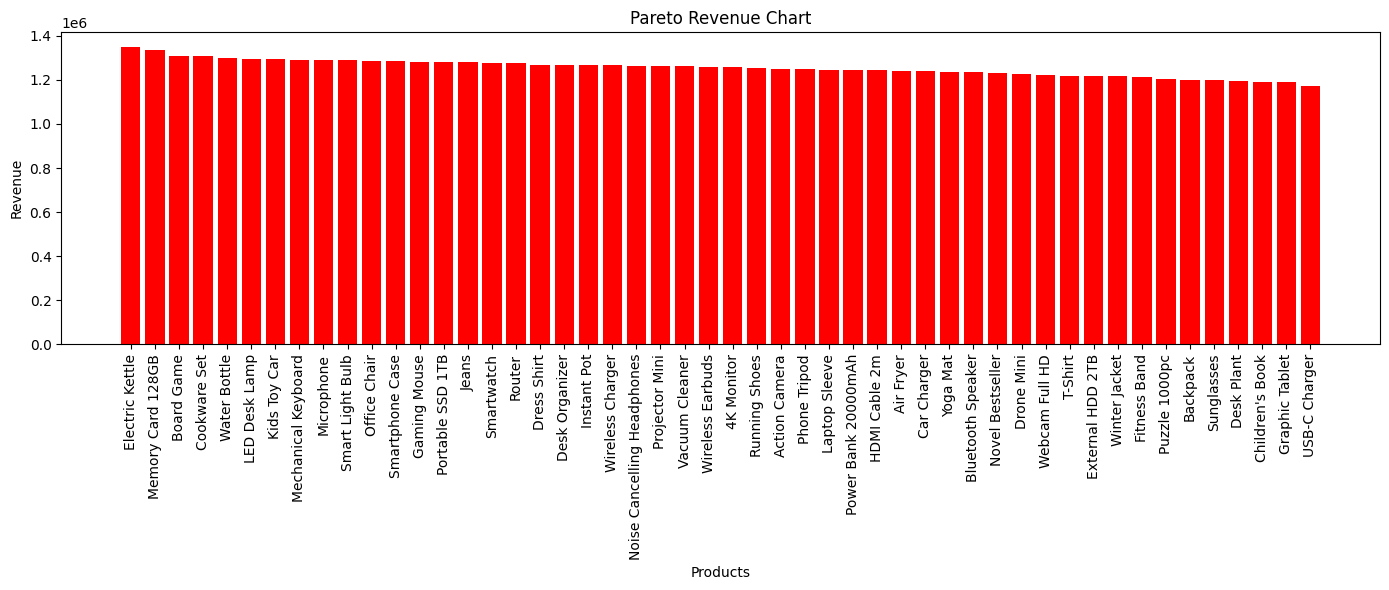

In [25]:
plt.figure(figsize=(14,6))

plt.bar(product_rev["Product"],product_rev["Revenue"],color = "red")

plt.xticks(rotation=90)

plt.title("Pareto Revenue Chart")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

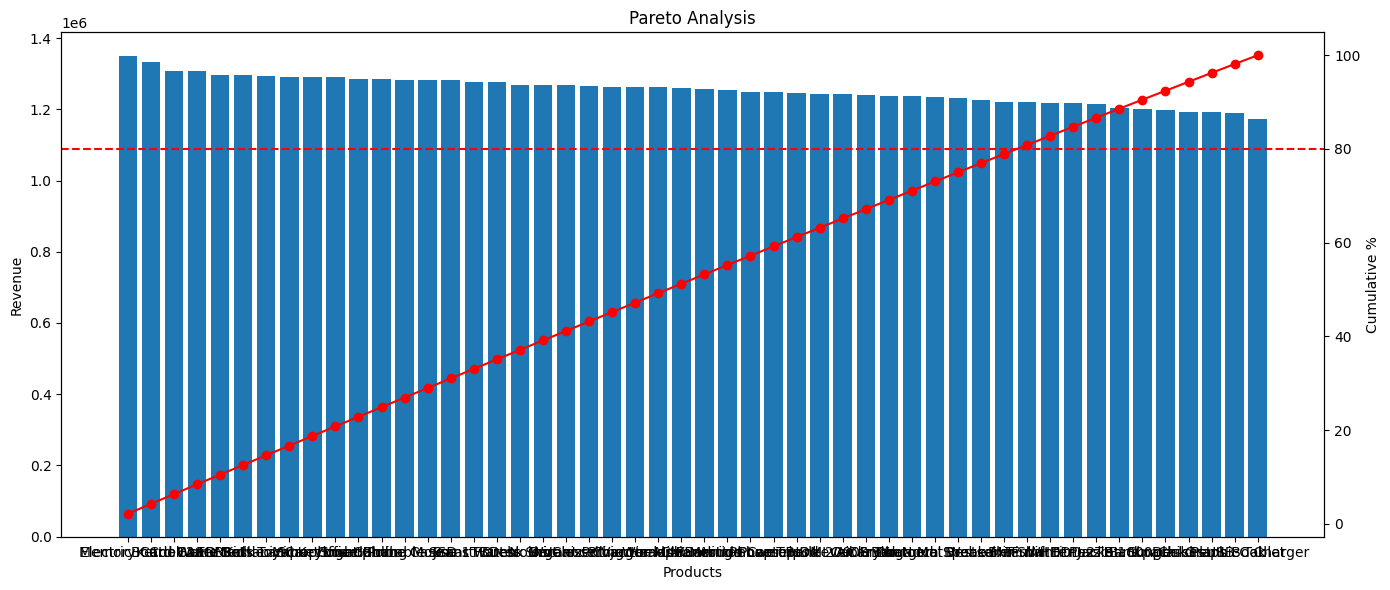

In [23]:
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(product_rev["Product"],product_rev["Revenue"])

ax2 = ax1.twinx()

ax2.plot(product_rev["Product"],product_rev["CumulativePct"],marker="o",color = "red")

ax2.axhline(y=80,linestyle="--",color = "red")

ax1.set_xlabel("Products")
ax1.set_ylabel("Revenue")
ax2.set_ylabel("Cumulative %")

plt.xticks(rotation=90)

plt.title("Pareto Analysis")

plt.tight_layout()
plt.show()

In [13]:
monthly_agg = (df.groupby("Month").agg(
        TotalQty=("Quantity", "sum"),
        AvgDiscount=("Discount", "mean")
    )
    .reset_index()
)

monthly_agg

,Month,TotalQty,AvgDiscount
0,1,19694,0.074294
1,2,17119,0.073954
2,3,18743,0.074271
3,4,18352,0.074228
4,5,19271,0.073929
5,6,18710,0.075332
6,7,18927,0.074480
7,8,19231,0.072998
8,9,18294,0.073885
9,10,18440,0.075526


In [14]:
X = monthly_agg[["Month", "AvgDiscount"]]

y = monthly_agg["TotalQty"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

r2 = r2_score(y_test,y_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

MAE : 1046.79
RMSE: 1131.14
R²  : -1.6467


In [20]:
avg_discount = monthly_agg["AvgDiscount"].mean()

next_month = pd.DataFrame({"Month": [1],"AvgDiscount": [avg_discount]})
next_prediction = model.predict(next_month)[0]

print("Predicted Next Month Sales:", round(next_prediction))

Predicted Next Month Sales: 18104


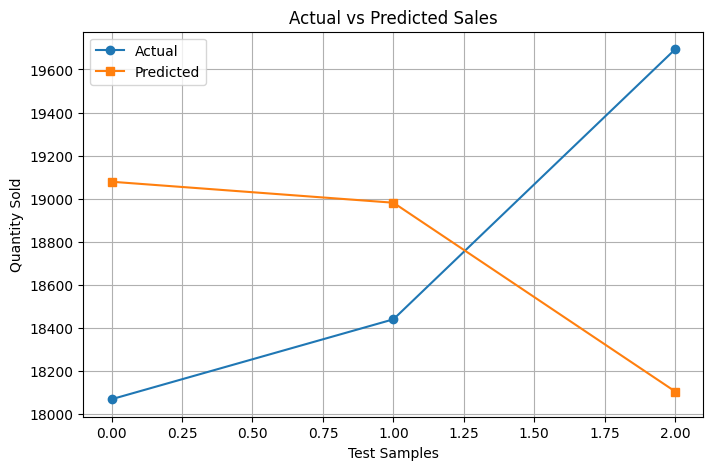

In [18]:
plt.figure(figsize=(8,5))
plt.plot(range(len(y_test)),y_test.values,marker="o",label="Actual")

plt.plot(range(len(y_pred)),y_pred,marker="s",label="Predicted")

plt.title("Actual vs Predicted Sales")

plt.xlabel("Test Samples")
plt.ylabel("Quantity Sold")

plt.legend()
plt.grid(True)

plt.show()